# Génération de Texte avec les Chaînes de Markov

Ce notebook explore comment utiliser les chaînes de Markov pour générer du texte de manière probabiliste.

### Qu'est-ce qu'une chaîne de Markov ?
Une chaîne de Markov est un système mathématique qui subit des transitions d'un état à un autre. La caractéristique principale est que la probabilité de passer à l'état suivant dépend **uniquement** de l'état actuel, et non de la séquence d'événements qui l'ont précédé.

### 1. Préparation des données
Nous allons d'abord définir une fonction pour nettoyer et segmenter notre texte d'entrée.

In [1]:
import random
import re
from collections import defaultdict

def clean_text(text):
    # Nettoyage basique : minuscules et suppression de la ponctuation complexe
    text = text.lower()
    words = re.findall(r"\w+", text)
    return words

text_sample = """
Le petit chat boit du lait.
Le petit chien mange sa soupe.
Le chat court dans le jardin.
Le chien aboie contre le petit chat."""
words = clean_text(text_sample)
print(f"Exemple de mots extraits : {words[:10]}")

Exemple de mots extraits : ['le', 'petit', 'chat', 'boit', 'du', 'lait', 'le', 'petit', 'chien', 'mange']


### 2. Construction du Modèle
Le modèle repose sur un dictionnaire où chaque mot est une clé, et la valeur est une liste de tous les mots qui le suivent dans le texte source.

In [2]:
def build_markov_model(words, order=1):
    model = defaultdict(list)
    for i in range(len(words) - order):
        state = tuple(words[i:i + order])
        next_word = words[i + order]
        model[state].append(next_word)
    return model

# Création d'un modèle d'ordre 1 (un mot prédit le suivant)
model = build_markov_model(words, order=1)

# Visualisation d'une transition
print("Transitions possibles après 'petit':", model[('petit',)])

Transitions possibles après 'petit': ['chat', 'chien', 'chat']


### Visualisation du Graphe de Transition
Pour rendre le modèle plus concret, visualisons les relations entre les mots. Chaque flèche indique qu'un mot peut être suivi par un autre.

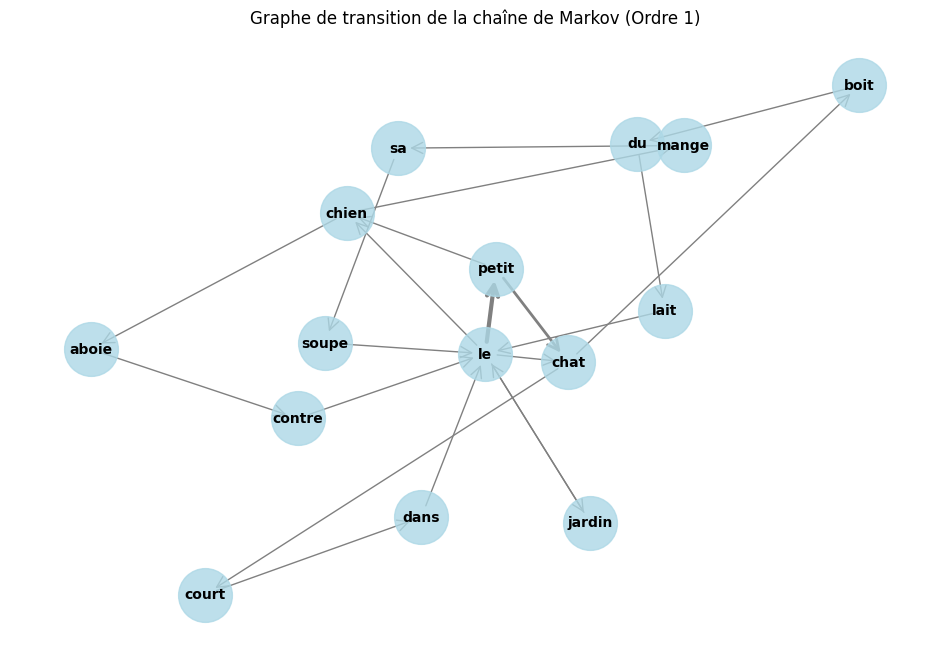

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_markov_graph(model):
    G = nx.DiGraph()

    # Ajout des arrêtes à partir du modèle
    for state, next_words in model.items():
        origin = " ".join(state)
        for target in next_words:
            if G.has_edge(origin, target):
                G[origin][target]['weight'] += 1
            else:
                G.add_edge(origin, target, weight=1)

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.5)

    # Dessiner les nœuds et les labels
    nx.draw_networkx_nodes(G, pos, node_size=1500, node_color='lightblue', alpha=0.8)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    # Dessiner les liens avec une épaisseur proportionnelle au poids
    edges = G.edges(data=True)
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20,
                           edge_color='gray',
                           width=[d['weight'] for u, v, d in edges])

    plt.title("Graphe de transition de la chaîne de Markov (Ordre 1)")
    plt.axis('off')
    plt.show()

plot_markov_graph(model)

### 4. Modèle Bigramme (Ordre 2)
Dans un modèle d'ordre 2, l'état n'est plus un mot seul, mais un couple de mots.

In [6]:
# Création du modèle d'ordre 2
model_bigram = build_markov_model(words, order=2)

# Exemple de transition pour un bigramme
state_example = ('le', 'petit')
print(f"Après {state_example}, les mots possibles sont : {model_bigram[state_example]}")

Après ('le', 'petit'), les mots possibles sont : ['chat', 'chien', 'chat']


### 5. Graphe avec Probabilités
Calculons les probabilités de transition (fréquence d'apparition / total des transitions possibles pour un état) et affichons-les sur les flèches.

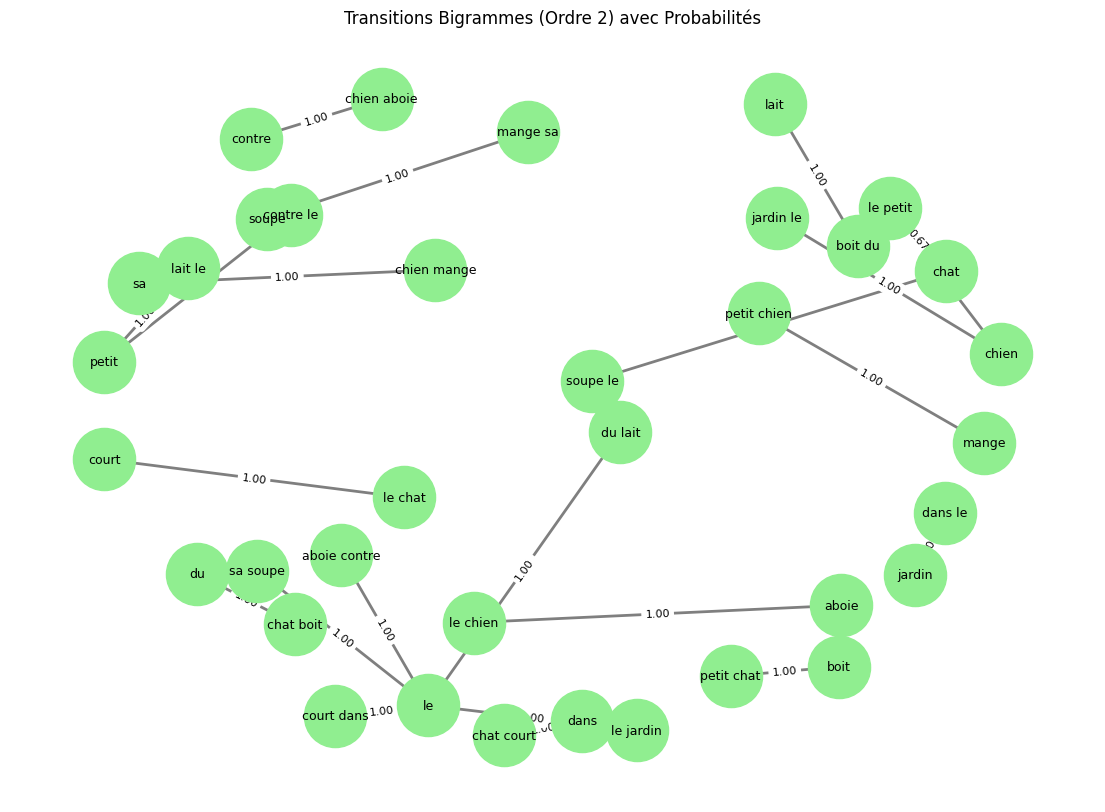

In [7]:
def plot_weighted_markov(model, title="Graphe de Probabilités"):
    G = nx.DiGraph()

    for state, next_words in model.items():
        origin = " ".join(state)
        total = len(next_words)
        # Compter les occurrences de chaque destination
        counts = defaultdict(int)
        for w in next_words: counts[w] += 1

        for target, count in counts.items():
            prob = count / total
            G.add_edge(origin, target, weight=prob)

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=0.7)

    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightgreen')
    nx.draw_networkx_labels(G, pos, font_size=9)

    # Dessiner les liens
    edges = G.edges(data=True)
    nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, arrowsize=20)

    # Ajouter les probabilités sur les liens
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(title)
    plt.axis('off')
    plt.show()

# Visualisons le modèle bigramme
plot_weighted_markov(model_bigram, title="Transitions Bigrammes (Ordre 2) avec Probabilités")

### 3. Génération de texte
Pour générer du texte, on choisit un point de départ, puis on tire au sort le mot suivant parmi les possibilités stockées.

In [5]:
def generate_text(model, start_words, length=20):
    current_state = tuple(start_words)
    result = list(start_words)

    for _ in range(length):
        possible_next = model.get(current_state)
        if not possible_next:
            break
        next_word = random.choice(possible_next)
        result.append(next_word)
        current_state = tuple(result[-len(current_state):])

    return " ".join(result)

# Génération de 15 mots en commençant par 'le'
generated = generate_text(model, ['petit'], length=2)
print(f"Texte généré : {generated}")

Texte généré : petit chat court


### 6. Exemple Grandeur Nature : Alice au Pays des Merveilles
Pour voir des résultats plus créatifs, nous allons utiliser un texte classique complet.

In [27]:
import requests

# Téléchargement du texte intégral d'Alice (Henri Bué)
url = "https://www.gutenberg.org/cache/epub/19651/pg19651.txt"

try:
    response = requests.get(url)
    response.encoding = 'utf-8'
    full_text = response.text

    # Recherche d'un marqueur plus commun
    if "CHAPITRE I" in full_text:
        alice_text = full_text[full_text.find("CHAPITRE I"):]
    else:
        alice_text = full_text

except Exception as e:
    print(f"Erreur : {e}")
    alice_text = "Alice commençait à se sentir très lasse..."

print(f"Taille du texte : {len(alice_text)} caractères.")
alice_words = clean_text(alice_text)
alice_model = build_markov_model(alice_words, order=2)

print(f"Nombre de mots : {len(alice_words)}")
print(f"Nombre d'états : {len(alice_model)}")

Taille du texte : 345885 caractères.
Nombre de mots : 61750
Nombre d'états : 36017


Générons maintenant un paragraphe entier à partir de ce modèle plus complexe.

In [28]:
# Génération finale avec le texte français complet
start_fr = ['alice', 'était']
# On s'assure que le point de départ existe
if tuple(start_fr) not in alice_model:
    start_fr = list(random.choice(list(alice_model.keys())))

generated_alice_fr = generate_text(alice_model, start_fr, length=100)

print("Texte généré (Modèle Bigramme Français) :")
print("-" * 30)
print(generated_alice_fr)
print("-" * 30)

Texte généré (Modèle Bigramme Français) :
------------------------------
followed orders a shelf of rock after ashe made the final adjustments and then another hand to a project gutenberg 1 e 1 the following sentence with active links to or distributing this work or any files containing a part of ross when he faced it so yet i have seen happen here two five ten thousand years in his limited hawaikan vocabulary possess weapons and strength but on soft surface a mat of gray living sod where his own moves the foanna powers had touched him a paralyzer ross slewed around dragging the alien up and out what had happened to
------------------------------
